## Exploratory Data Analysis for Tree Survival Prediction

This project uses the new TreeO2 (Dec 5) data to understand and predict tree survival rates across different farms in Timor-Leste. Survival outcomes are explored through charts and visual analysis alongside environmental conditions such as rainfall, temperature, soil pH, elevation, and slope to identify patterns, risks, and other limiting factors that affect tree survival. These insights are then used to train a machine learning model that predicts tree survival likelihood before planting, and helps field staff make better planting decisions.

In [10]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely import wkt

### Load and combine TreeO2 (Dec 5) data files

#### Input Files
 The following files must be placed in a datasets/TreeO2 (Dec5) directory in the same directory as this notebook (datascience/notebooks/) before running. They are not committed to the repository due to privacy reasons and must be sourced from MS Teams at: Planting optimisation tool > Shared > Datasets > TreeO2 (Dec 5)

Files:
- GS4210_Baguia_Tree_Data_1.csv
- GS4210_Baguia_Tree_Data_2.csv
- GS4210_Baguia_Tree_Data_3.csv
- GS4210_Baguia_Tree_Data_4.csv
- GS4210_Baguia_Tree_Data_5.csv
- GS4210_Baguia_Tree_Data_6.csv
- GS11743_CCC_Covalima_Tree_Data (1).csv
- GS11800_TV_Baucau_Tree_Data (1).csv
- GS11801_NETIL_Liquica_Tree_Data (1).csv
- RM_Lautem-Lospalos_Tree_Data.csv
- RM_Quelicai-Laga_Tree_Data.csv
- RM_Viqueque-Uatucarbau-Uatulari_Tree_Data.csv

#### Output Files
Running this notebook exports the following files (committed):
- datascience/data/treeo2_dec5_cleaned.csv.gz - cleaned TreeO2 data that can be used for survivability and growth modelling.

In [2]:
# Load all TreeO2 (Dec 5) CSV files
tree_files = [
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_1.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_2.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_4.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_5.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_6.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_3.csv",
    "datasets/TreeO2 (Dec 5)/GS11743_CCC_Covalima_Tree_Data (1).csv",
    "datasets/TreeO2 (Dec 5)/GS11800_TV_Baucau_Tree_Data (1).csv",
    "datasets/TreeO2 (Dec 5)/GS11801_NETIL_Liquica_Tree_Data (1).csv",
    "datasets/TreeO2 (Dec 5)/RM_Lautem-Lospalos_Tree_Data.csv",
    "datasets/TreeO2 (Dec 5)/RM_Quelicai-Laga_Tree_Data.csv",
    "datasets/TreeO2 (Dec 5)/RM_Viqueque-Uatucarbau-Uatulari_Tree_Data.csv",
]

# Read each file and store in a list
df_list = []

for f in tree_files:
    df_tmp = pd.read_csv(f, dtype=str, low_memory=False)

    # Add farm column based on filename
    df_tmp["farm"] = os.path.basename(f).replace(".csv", "")

    df_list.append(df_tmp)

# Combine all TreeO2 (Dec 5) files into one DataFrame
treeo2_dec5_df = pd.concat(df_list, ignore_index=True)

### Remove Duplicates

In [3]:
# Remove all duplicate rows from DataFrame and reset the index
treeo2_dec5_df = treeo2_dec5_df.drop_duplicates().reset_index(drop=True)

# Confirm that no duplicates remain
treeo2_dec5_df.duplicated().sum()

np.int64(0)

### Clean and prepare the TreeO2 (Dec 5) dataset

In [4]:
# Drop farm column
treeo2_dec5_df = treeo2_dec5_df.drop(columns=["farm", "scanned_to_farmer_id"], errors="ignore")

# Fill missing species names with blank text
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].fillna("")

# Remove everything inside the brackets
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace(r"\(.*?\)", "", regex=True)

# Remove all spaces
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace(" ", "")

# Fix hyphen spacing (from Ai- mahony to Ai-mahony)
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace("- ", "-")
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace(" -", "-")

# Capitialise the tree species
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.capitalize()

# Convert trunk circumference to numeric and drop rows without any entry
treeo2_dec5_df["trunk_circumference"] = pd.to_numeric(treeo2_dec5_df["trunk_circumference"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["trunk_circumference"])

# Convert planted_year to integer dropping rows without any entry
treeo2_dec5_df["planted_year"] = pd.to_numeric(treeo2_dec5_df["planted_year"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["planted_year"])
treeo2_dec5_df["planted_year"] = treeo2_dec5_df["planted_year"].astype(int)

# Convert planted_month to integer dropping rows without any entry
treeo2_dec5_df["planted_month"] = pd.to_numeric(treeo2_dec5_df["planted_month"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["planted_month"])
treeo2_dec5_df["planted_month"] = treeo2_dec5_df["planted_month"].astype(int)

# Convert scan_date to datetime object
treeo2_dec5_df["scan_date"] = pd.to_datetime(treeo2_dec5_df["scan_date"])

# Convert latitude and longitude to numeric values
treeo2_dec5_df[["latitude", "longitude"]] = treeo2_dec5_df[["latitude", "longitude"]].apply(pd.to_numeric, errors="coerce")

# Convert farmer_card_id to integer dropping rows without any entry
treeo2_dec5_df["farmer_card_id"] = pd.to_numeric(treeo2_dec5_df["farmer_card_id"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["farmer_card_id"])
treeo2_dec5_df["farmer_card_id"] = treeo2_dec5_df["farmer_card_id"].astype(int)

# Standardise known species errors in TreeO2 dataset
species_aliases = {
    "eucalyptus": "Ai-bubur (mutin)",
    "ai-kamelii": "Ai-kamelli",
    "ai-bubur": "Ai-bubur (mutin)",
}

tree_species_clean = treeo2_dec5_df["tree_species"].fillna("").astype(str).str.strip()

tree_species_norm = tree_species_clean.str.lower()
for alias_norm, canonical_name in species_aliases.items():
    tree_species_clean = tree_species_clean.mask(tree_species_norm.eq(alias_norm), canonical_name)

treeo2_dec5_df["tree_species"] = tree_species_clean

### Detecting recycled fob_id

In [5]:
# Detecting recycled fob_ids
# ====================== Settings ==================================================================
JUMP_THRES = 50  # Max distance moved (metres) before flagging
CIRC_DROP_THRES = 0.8  # Minimum fraction of tree circumference drop to flag — filters measurement noise


# Helper function for Haversine distance (approximate metres)
def haversine_vectorized(lat1, lon1, lat2, lon2):
    r = 6371000.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


# Ensure chronological order within each fob_id, reset index for safe duplicated() usage
treeo2_dec5_df = treeo2_dec5_df.sort_values(["fob_id", "scan_date"], kind="mergesort").reset_index(drop=True)

# Group by fob_id
grouped = treeo2_dec5_df.groupby("fob_id", sort=False)

# Previous values within fob_id
treeo2_dec5_df["prev_lat"] = grouped["latitude"].shift(1)
treeo2_dec5_df["prev_lon"] = grouped["longitude"].shift(1)
treeo2_dec5_df["species_prev"] = grouped["tree_species"].shift(1)
treeo2_dec5_df["year_prev"] = grouped["planted_year"].shift(1)
treeo2_dec5_df["circ_prev"] = grouped["trunk_circumference"].shift(1)
treeo2_dec5_df["farm_prev"] = grouped["farmer_card_id"].shift(1)

# First-row mask (after reset_index, duplicated() is positionally safe)
is_first_in_fob = ~treeo2_dec5_df["fob_id"].duplicated()

# Calculate spatial jump distance
treeo2_dec5_df["dist_moved_m"] = haversine_vectorized(treeo2_dec5_df["latitude"], treeo2_dec5_df["longitude"], treeo2_dec5_df["prev_lat"], treeo2_dec5_df["prev_lon"])

# Change flags — all explicitly exclude first row per fob
treeo2_dec5_df["species_changed"] = (treeo2_dec5_df["tree_species"] != treeo2_dec5_df["species_prev"]) & ~is_first_in_fob & treeo2_dec5_df["species_prev"].notna()

treeo2_dec5_df["year_changed"] = (treeo2_dec5_df["planted_year"] != treeo2_dec5_df["year_prev"]) & ~is_first_in_fob & treeo2_dec5_df["year_prev"].notna()

treeo2_dec5_df["circ_dropped"] = (treeo2_dec5_df["trunk_circumference"] < (treeo2_dec5_df["circ_prev"] * CIRC_DROP_THRES)) & ~is_first_in_fob & treeo2_dec5_df["circ_prev"].notna()

treeo2_dec5_df["spatial_jump"] = (treeo2_dec5_df["dist_moved_m"] > JUMP_THRES) & ~is_first_in_fob

# NEW: fob_id appeared on a different farm — very strong recycling signal
treeo2_dec5_df["farm_changed"] = (treeo2_dec5_df["farmer_card_id"] != treeo2_dec5_df["farm_prev"]) & ~is_first_in_fob & treeo2_dec5_df["farm_prev"].notna()

# ====================== Reason labels ============================================================
# Priority order: most-evidence combos first so they aren't masked by simpler rules
conditions = [
    # Farm change combos (strongest signal)
    (treeo2_dec5_df["farm_changed"] & treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["farm_changed"] & treeo2_dec5_df["species_changed"]),
    (treeo2_dec5_df["farm_changed"] & treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["farm_changed"]),
    # Species-change combos
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"] & treeo2_dec5_df["spatial_jump"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["spatial_jump"]),
    (treeo2_dec5_df["species_changed"]),
    # Non-species composites
    (treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"] & treeo2_dec5_df["spatial_jump"]),
    (treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["spatial_jump"]),
]
choices = [
    "Farm Transfer + Species + Year",
    "Farm Transfer + Species",
    "Farm Transfer + Year",
    "Farm Transfer Only",
    "Full Reset (Species, Year, Size, Location)",
    "Replacement (Species, Year & Size)",
    "Species + Year Updated",
    "Species + Size Drop",
    "Species + Location Jump",
    "Biological Reset (Species Changed)",
    "Partial Reset (Year, Size & Location)",
    "Standard Replacement (Year & Size)",
    "Admin Update Only (Year Changed)",
    "Size Drop Only",
    "Spatial Shift (Location Jumped)",
]
treeo2_dec5_df["recycle_reason"] = np.select(conditions, choices, default="Normal")

# ====================== Aggregate flags ==========================================================
any_change_cols = ["species_changed", "year_changed", "circ_dropped", "spatial_jump", "farm_changed"]
treeo2_dec5_df["any_change"] = treeo2_dec5_df[any_change_cols].any(axis=1)

# ====================== Life cycle numbering =====================================================
# cumsum within fob: the row where a change is detected becomes row 1 of the new life cycle
treeo2_dec5_df["life_cycle_number"] = treeo2_dec5_df.groupby("fob_id")["any_change"].cumsum().astype(int) + 1

# Unique tree instance identifier
treeo2_dec5_df["tree_instance_id"] = treeo2_dec5_df["fob_id"].astype(str) + "_v" + treeo2_dec5_df["life_cycle_number"].astype(str)

# ====================== is_dead column ===========================================================
# A tree instance is dead if a later life cycle exists for the same fob_id
# (i.e. the fob was recycled, meaning the previous tree died)
max_life_per_fob = treeo2_dec5_df.groupby("fob_id")["life_cycle_number"].transform("max")
treeo2_dec5_df["is_dead"] = (treeo2_dec5_df["life_cycle_number"] < max_life_per_fob).astype(int)

# ====================== checks / summary ==================================================
# FOBs spanning multiple farms (pre-filter check)
farms_per_fob = treeo2_dec5_df.groupby("fob_id")["farmer_card_id"].nunique()
print(f"FOBs spanning multiple farms : {(farms_per_fob > 1).sum()}")

fobs_with_species_change = treeo2_dec5_df.groupby("fob_id")["species_changed"].any()
print(f"FOBs with ≥1 species change  : {int(fobs_with_species_change.sum())}")

fobs_with_any_change = treeo2_dec5_df.groupby("fob_id")["any_change"].any()
print(f"FOBs with ≥1 change (any)    : {int(fobs_with_any_change.sum())}")

# Breakdown by reason at fob level
fob_reason_breakdown = treeo2_dec5_df[treeo2_dec5_df["recycle_reason"] != "Normal"].groupby("recycle_reason")["fob_id"].nunique().sort_values(ascending=False)
print("\nRecycle reason breakdown (unique fob_ids):")
print(fob_reason_breakdown.to_string())

# Per-fob summary
recycled_summary = treeo2_dec5_df.groupby("fob_id")[any_change_cols].any()
recycled_summary["is_recycled"] = recycled_summary.any(axis=1)

# Life cycle distribution
multi_life_counts = treeo2_dec5_df.groupby("fob_id")["life_cycle_number"].max().value_counts().sort_index()
print("\nBreakdown of fob_id life cycles:")
for lives, count in multi_life_counts.items():
    print(f"  {lives} life cycle(s): {count:,} unique fob_ids")

# is_dead summary
print(f"\nTotal tree-instance rows marked is_dead=1 : {treeo2_dec5_df['is_dead'].sum():,}")
print(f"Total tree-instance rows marked is_dead=0 : {(treeo2_dec5_df['is_dead'] == 0).sum():,}")

FOBs spanning multiple farms : 17333
FOBs with ≥1 species change  : 2381
FOBs with ≥1 change (any)    : 42462

Recycle reason breakdown (unique fob_ids):
recycle_reason
Spatial Shift (Location Jumped)       16826
Farm Transfer Only                    15319
Size Drop Only                         7372
Farm Transfer + Year                   1942
Biological Reset (Species Changed)     1865
Species + Size Drop                     193
Farm Transfer + Species + Year          150
Species + Location Jump                 118
Farm Transfer + Species                  77

Breakdown of fob_id life cycles:
  1 life cycle(s): 549,378 unique fob_ids
  2 life cycle(s): 36,138 unique fob_ids
  3 life cycle(s): 5,932 unique fob_ids
  4 life cycle(s): 362 unique fob_ids
  5 life cycle(s): 28 unique fob_ids
  7 life cycle(s): 1 unique fob_ids
  19 life cycle(s): 1 unique fob_ids

Total tree-instance rows marked is_dead=1 : 56,594
Total tree-instance rows marked is_dead=0 : 961,648


#### Get the most recent records for every unique tree instance

In [6]:
# This ensures we only count each tree (or recycled version) once.
latest_tree_stats = treeo2_dec5_df.sort_values("scan_date").groupby("tree_instance_id").tail(1)

# Generate the Status Summary
status_summary = latest_tree_stats["is_dead"].value_counts()

# Calculate Percentages for context
status_percent = latest_tree_stats["is_dead"].value_counts(normalize=True) * 100

# Combine into a readable table
summary_df = pd.DataFrame({"Total Trees": status_summary, "Percentage (%)": status_percent.round(2)})

print("\n=== Tree Inventory Summary ===")
print(summary_df)


=== Tree Inventory Summary ===
         Total Trees  Percentage (%)
is_dead                             
0             591840           92.32
1              49224            7.68


### Update longitude and latitude

In [7]:
# Treat sentinel values as missing
treeo2_dec5_df[["latitude", "longitude"]] = treeo2_dec5_df[["latitude", "longitude"]].replace(-1, pd.NA)

# Compute the farm centroids
farm_centroids = treeo2_dec5_df.groupby("farmer_card_id").agg({"latitude": "mean", "longitude": "mean"})
print(f"Farms with no centroid value: {farm_centroids.isnull().sum().max()}")

# Fill missing latitude using the centroids per farm
treeo2_dec5_df["latitude"] = treeo2_dec5_df["latitude"].combine_first(treeo2_dec5_df["farmer_card_id"].map(farm_centroids["latitude"]).astype(float))

# Fill missing longitude using reference longitude per farm
treeo2_dec5_df["longitude"] = treeo2_dec5_df["longitude"].combine_first(treeo2_dec5_df["farmer_card_id"].map(farm_centroids["longitude"]).astype(float))

# Drop rows with missing latitude or longitude
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["latitude", "longitude"])

# Show remaining missing values for latitude and longitude
print(f"Farms with no centroid value after cleaning: {treeo2_dec5_df.isnull().sum()[['latitude', 'longitude']].max()}")

Farms with no centroid value: 16
Farms with no centroid value after cleaning: 0


In [8]:
# Remove columns that are not required
cols_to_drop = [
    "fob_id",
    "farmer_card_id",
    "prev_lat",
    "prev_lon",
    "species_prev",
    "year_prev",
    "circ_prev",
    "farm_prev",
    "farm_changed",
    "dist_moved_m",
    "species_changed",
    "year_changed",
    "circ_dropped",
    "spatial_jump",
    "recycle_reason",
    "any_change",
    "life_cycle_number",
    "max_life_for_this_fob",
    "is_alive",
    "days_since_last_scan",
]
treeo2_dec5_df = treeo2_dec5_df.drop(columns=cols_to_drop, errors="ignore")
treeo2_dec5_df = treeo2_dec5_df.reset_index(drop=True)

### Add farm_id

In [9]:
# Read farm boundaries
farms = pd.read_csv("../../backend/src/scripts/data/farm_boundaries_master.csv").rename(columns={"external_id": "farm_id", "boundary": "geometry"})
farms["geometry"] = farms["geometry"].apply(wkt.loads)

farms_gdf = gpd.GeoDataFrame(farms, geometry="geometry", crs="EPSG:4326")

cols_to_exclude = ["longitude", "latitude"]

# Build point geometries (x=lon, y=lat)
points_gdf = gpd.GeoDataFrame(
    treeo2_dec5_df.drop(columns=cols_to_exclude).copy(),
    geometry=gpd.points_from_xy(treeo2_dec5_df["longitude"], treeo2_dec5_df["latitude"]),
    crs="EPSG:4326",  # set to WGS84 as the lat/lon are geographic degrees
)

points_proj = points_gdf.to_crs("EPSG:32752")
farms_proj = farms_gdf.to_crs("EPSG:32752")

# Returns only points that fall within at least one polygon
joined = gpd.sjoin(points_proj, farms_proj[["farm_id", "geometry"]], how="left", predicate="within")

# Prepare distance column now (important)
joined["nearest_dist"] = pd.NA
unmatched_idx = joined.index[joined["farm_id"].isna()]
joined_nearest = gpd.sjoin_nearest(points_proj.loc[unmatched_idx], farms_proj[["farm_id", "geometry"]], how="left", distance_col="nearest_dist")

p95_dist = joined_nearest["nearest_dist"].dropna().quantile(0.95)

print(f"95th percentile nearest distance: {p95_dist:.0f} meters")

ABSOLUTE_MAX = 5000  # meters
distance_cutoff = min(p95_dist, ABSOLUTE_MAX)

print(f"Using distance cutoff: {distance_cutoff:.0f} meters")

too_far = joined_nearest["nearest_dist"] > distance_cutoff

joined_nearest.loc[too_far, "farm_id"] = pd.NA
joined_nearest.loc[too_far, "nearest_dist"] = pd.NA

joined.loc[unmatched_idx] = joined_nearest.reindex(joined.columns, axis=1)
joined["match_type"] = "unmatched"
joined.loc[joined["farm_id"].notna(), "match_type"] = "within"
joined.loc[joined["nearest_dist"].notna(), "match_type"] = "nearest"

print(joined["match_type"].value_counts())

# Drop trees with no farm match (either within or nearest)
joined = joined.dropna(subset=["farm_id"])
joined["farm_id"] = joined["farm_id"].astype(int)

95th percentile nearest distance: 2128 meters
Using distance cutoff: 2128 meters
match_type
nearest      652138
within       331385
unmatched     34323
Name: count, dtype: int64


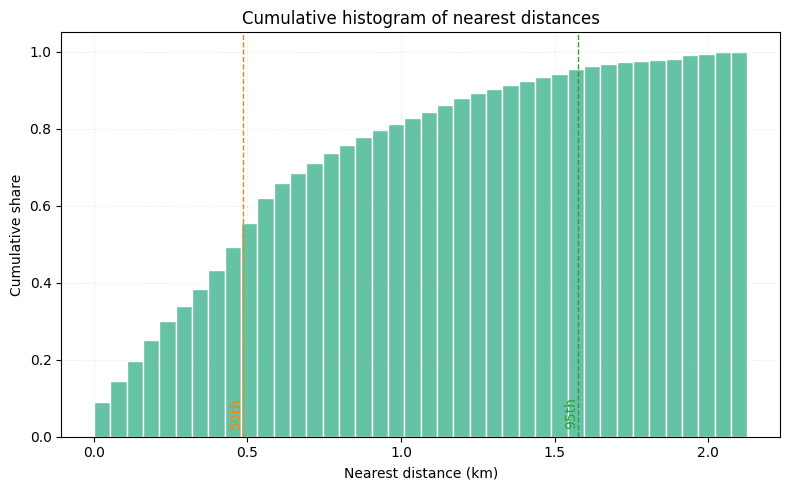

In [10]:
x_km = joined_nearest["nearest_dist"].dropna().astype(float) / 1000.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    x_km,
    bins=40,
    cumulative=True,
    density=True,  # scales to 0–1 so it reads like an ECDF
    color="#66c2a5",
    edgecolor="white",
)
# Optional: annotate key percentiles
p50 = np.percentile(x_km, 50)
p95 = np.percentile(x_km, 95)
ax.axvline(p50, color="#ff7f0e", linestyle="--", linewidth=1)
ax.axvline(p95, color="#2ca02c", linestyle="--", linewidth=1)
ax.text(p50, 0.02, "50th", rotation=90, va="bottom", ha="right", color="#ff7f0e")
ax.text(p95, 0.02, "95th", rotation=90, va="bottom", ha="right", color="#2ca02c")
ax.set_xlabel("Nearest distance (km)")
ax.set_ylabel("Cumulative share")
ax.set_title("Cumulative histogram of nearest distances")
ax.grid(alpha=0.3, linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

In [11]:
result_df = joined.drop(columns=[c for c in joined.columns if c not in treeo2_dec5_df.columns and c not in ["farm_id"]])

In [12]:
# Reorder result_df columns using exact column names only
column_order = [
    "farm_id",
    "tree_instance_id",
    "tree_species",
    "planted_year",
    "planted_month",
    "scan_date",
    "trunk_circumference",
    "is_dead",
]

remaining_cols = [c for c in result_df.columns if c not in column_order]
result_df = result_df[column_order + remaining_cols]

result_df.to_csv(os.path.join("../data/treeo2_dec5_cleaned.csv.gz"), index=False)

### Model Training

#### What This Model Does

This pipeline predicts whether a tree will **survive** or **die** given the environmental conditions at its planting location and basic information about the tree itself.

#### Target Variable
- **`survived`** - binary label: 1=alive, 0=dead. Derived by inverting `is_dead`, which was assigned during the recycled FOB detection step: a tree is marked dead when its FOB tag was later reused for a different tree.

#### Features
| Feature | Description |
|---|---|
| `temp_mean` | Mean temperature at the farm (°C) |
| `rain_mean` | Mean annual rainfall at the farm (mm) |
| `elev_mean` | Mean elevation of the farm (m) |
| `slope_mean` | Mean slope of the farm (degrees) |
| `ph` | Soil pH at the farm |
| `correct_tree_species_name` | Normalised tree species name (one-hot encoded) |
| `trunk_circumference` | Circumference of the trunk at time of scan (cm) |
| `planted_month` | Month the tree was planted |
| `age_months` | Age of the tree in months at time of scan |
| `rain_outside_opt` | How far rainfall deviates from this species's optimal range |
| `temp_outside_opt` | How far temperature deviates from this species's optimal range |
| `elev_outside_opt` | How far elevation deviates from this species's optimal range |
| `ph_outside_opt` | How far soil pH deviates from this species's optimal range |

The four `*_outside_opt` features are engineered distances, zero if the farm condition is within the species's known optimal range, and positive otherwise. They give the model a signal about how hostile the environment is relative to what each species prefers, without requiring the model to learn species-specific thresholds from scratch.

#### Pipeline Overview
1. **Preprocessing** - Species names are one-hot encoded and all numeric features are passed through as-is via a `ColumnTransformer`.
2. **Resampling (Case 5 only)** - SMOTE-ENN is applied to address the class imbalance between alive and dead trees.
3. **Classifier** - Multiple classifiers are compared (Random Forest and LightGBM), with and without class weighting and probability threshold tuning.
4. **Threshold tuning** - For Cases 3-6, the decision threshold is moved on the validation set by maximising the **F2 score** for the "Died" class, recall is weighted twice as heavily as precision, because missing a tree that is going to die is more costly than a false alarm.

In [12]:
# Imports for model training

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

#### Load Dataset

In [13]:
tree_df = pd.read_csv("../data/treeo2_dec5_cleaned.csv.gz")
farm_df = pd.read_csv("../../backend/src/scripts/data/farm_master.csv").rename(columns={"external_id": "farm_id"})
species_df = pd.read_csv("../../backend/src/scripts/data/species_20251222.csv")

print(f"Tree records : {len(tree_df):,}")
print(f"Farms        : {len(farm_df):,}")
print(f"Species      : {len(species_df):,}")

Tree records : 983,523
Farms        : 3,200
Species      : 20


#### Merge and prepare the dataset

In [14]:
final_df = tree_df.merge(
    farm_df[["farm_id", "ph", "rainfall_mm", "temperature_celsius", "elevation_m", "slope"]],
    on="farm_id",
    how="left",
).rename(
    columns={
        "temperature_celsius": "temp_mean",
        "rainfall_mm": "rain_mean",
        "elevation_m": "elev_mean",
        "slope": "slope_mean",
    }
)

final_df["survived"] = 1 - final_df["is_dead"]
final_df["correct_tree_species_name"] = final_df["tree_species"].astype(str).str.strip().str.lower().str.capitalize()

ENV_FEATURES = ["temp_mean", "rain_mean", "elev_mean", "slope_mean", "ph"]
final_df = final_df.dropna(subset=ENV_FEATURES + ["survived"]).reset_index(drop=True)

survived_pct = final_df["survived"].value_counts(normalize=True) * 100
print("\nClass distribution:")
print(f"  Survived (1) : {survived_pct[1]:.2f}%")
print(f"  Died     (0) : {survived_pct[0]:.2f}%")


Class distribution:
  Survived (1) : 94.43%
  Died     (0) : 5.57%


#### Species optimal ranges
Used for prediction warnings

In [15]:
optima_df = (
    species_df[
        [
            "common_name",
            "rainfall_mm_min",
            "rainfall_mm_max",
            "temperature_celsius_min",
            "temperature_celsius_max",
            "elevation_m_min",
            "elevation_m_max",
            "ph_min",
            "ph_max",
        ]
    ]
    .rename(
        columns={
            "common_name": "species_name",
            "rainfall_mm_min": "rainfall_min",
            "rainfall_mm_max": "rainfall_max",
            "temperature_celsius_min": "temp_min",
            "temperature_celsius_max": "temp_max",
            "elevation_m_min": "alt_min",
            "elevation_m_max": "alt_max",
        }
    )
    .copy()
)
optima_df["species_name"] = optima_df["species_name"].astype(str).str.strip().str.lower().str.capitalize()

#### Feature Engineering

In [16]:
# Age in months from planting to scan date
final_df["scan_date"] = pd.to_datetime(final_df["scan_date"])
final_df["age_months"] = ((final_df["scan_date"].dt.year - final_df["planted_year"]) * 12 + (final_df["scan_date"].dt.month - final_df["planted_month"])).clip(lower=0)

# Species optimum distances — how far outside each species' comfort zone
opt = optima_df.rename(columns={"species_name": "correct_tree_species_name"})
final_df = final_df.merge(opt, on="correct_tree_species_name", how="left")


def _outside_range(val, lo, hi):
    """Distance outside [lo, hi]; 0 if inside the range."""
    return np.maximum(0, lo - val) + np.maximum(0, val - hi)


final_df["rain_outside_opt"] = _outside_range(final_df["rain_mean"], final_df["rainfall_min"], final_df["rainfall_max"])
final_df["temp_outside_opt"] = _outside_range(final_df["temp_mean"], final_df["temp_min"], final_df["temp_max"])
final_df["elev_outside_opt"] = _outside_range(final_df["elev_mean"], final_df["alt_min"], final_df["alt_max"])
final_df["ph_outside_opt"] = _outside_range(final_df["ph"], final_df["ph_min"], final_df["ph_max"])

# Fill 0 for trees with unknown species (no optimum data available)
opt_dist_cols = ["rain_outside_opt", "temp_outside_opt", "elev_outside_opt", "ph_outside_opt"]
final_df[opt_dist_cols] = final_df[opt_dist_cols].fillna(0)

# Drop the raw optimum bound columns — distances capture the signal
final_df = final_df.drop(columns=["rainfall_min", "rainfall_max", "temp_min", "temp_max", "alt_min", "alt_max", "ph_min", "ph_max"], errors="ignore")

# Drop rows missing trunk circumference or age
final_df = final_df.dropna(subset=["trunk_circumference", "age_months"]).reset_index(drop=True)

print(f"Rows after feature engineering : {len(final_df):,}")
new_cols = ["trunk_circumference", "planted_month", "age_months"] + opt_dist_cols
print("\nNew feature summary:")
print(final_df[new_cols].describe().round(2))

Rows after feature engineering : 983,523

New feature summary:
       trunk_circumference  planted_month  age_months  rain_outside_opt  \
count            983523.00      983523.00   983523.00         983523.00   
mean                 19.77           3.23       60.82             22.73   
std                  17.64           1.04       28.57             71.69   
min                   1.00           1.00        0.00              0.00   
25%                   8.90           3.00       41.00              0.00   
50%                  15.00           3.00       54.00              0.00   
75%                  25.90           4.00       75.00             21.00   
max                3010.00          12.00      188.00            929.00   

       temp_outside_opt  elev_outside_opt  ph_outside_opt  
count         983523.00         983523.00       983523.00  
mean               0.08              2.27            0.38  
std                0.55             37.88            0.32  
min                0.

#### ML Dataset Summary

In [17]:
ML_FEATURES = [
    "temp_mean",
    "rain_mean",
    "elev_mean",
    "slope_mean",
    "ph",
    "correct_tree_species_name",
    "trunk_circumference",
    "planted_month",
    "age_months",
    "rain_outside_opt",
    "temp_outside_opt",
    "elev_outside_opt",
    "ph_outside_opt",
]

ml_df = final_df[ML_FEATURES + ["survived"]]

print(f"ML dataset shape : {ml_df.shape[0]:,} rows × {len(ML_FEATURES)} features")
print(f"\nFeatures ({len(ML_FEATURES)}):")
for f in ML_FEATURES:
    print(f"  {f}")

print("\nMissing values per feature:")
nulls = ml_df[ML_FEATURES].isnull().sum()
missing = nulls[nulls > 0]
print(missing.to_string() if not missing.empty else "  None")

print("\nClass balance (target: survived):")
class_counts = ml_df["survived"].value_counts()
class_pct = ml_df["survived"].value_counts(normalize=True) * 100
for label, name in [(1, "Survived (1)"), (0, "Died     (0)")]:
    print(f"  {name} : {class_counts[label]:,}  ({class_pct[label]:.2f}%)")

print("\nNumeric feature statistics:")
numeric_features = [f for f in ML_FEATURES if f != "correct_tree_species_name"]
print(ml_df[numeric_features].describe().round(2).to_string())

ML dataset shape : 983,523 rows × 13 features

Features (13):
  temp_mean
  rain_mean
  elev_mean
  slope_mean
  ph
  correct_tree_species_name
  trunk_circumference
  planted_month
  age_months
  rain_outside_opt
  temp_outside_opt
  elev_outside_opt
  ph_outside_opt

Missing values per feature:
  None

Class balance (target: survived):
  Survived (1) : 928,730  (94.43%)
  Died     (0) : 54,793  (5.57%)

Numeric feature statistics:
       temp_mean  rain_mean  elev_mean  slope_mean         ph  trunk_circumference  planted_month  age_months  rain_outside_opt  temp_outside_opt  elev_outside_opt  ph_outside_opt
count  983523.00  983523.00  983523.00   983523.00  983523.00            983523.00      983523.00   983523.00         983523.00         983523.00         983523.00       983523.00
mean       23.94    2099.32     449.36       13.70       7.12                19.77           3.23       60.82             22.73              0.08              2.27            0.38
std         1.33     32

#### Train, validation and test split

In [18]:
FEATURES = [
    "temp_mean",
    "rain_mean",
    "elev_mean",
    "slope_mean",
    "ph",
    "correct_tree_species_name",
    "trunk_circumference",
    "planted_month",
    "age_months",
    "rain_outside_opt",
    "temp_outside_opt",
    "elev_outside_opt",
    "ph_outside_opt",
]

X = final_df[FEATURES]
y = final_df["survived"]

# Hold out 20 % as a final test set, then split the remainder 80/20 for val
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval)

print(f"\nTraining set   : {len(X_train):,} rows")
print(f"Validation set : {len(X_val):,} rows")
print(f"Test set       : {len(X_test):,} rows")


Training set   : 629,454 rows
Validation set : 157,364 rows
Test set       : 196,705 rows


#### Shared Preprocessor

In [19]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("species", OneHotEncoder(handle_unknown="ignore"), ["correct_tree_species_name"]),
            (
                "numeric",
                "passthrough",
                [
                    "temp_mean",
                    "rain_mean",
                    "elev_mean",
                    "slope_mean",
                    "ph",
                    "trunk_circumference",
                    "planted_month",
                    "age_months",
                    "rain_outside_opt",
                    "temp_outside_opt",
                    "elev_outside_opt",
                    "ph_outside_opt",
                ],
            ),
        ]
    )

#### Baseline model (always predicts majority class)

In [20]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

#### Case 1 - Random Forest (no class weighting)

In [21]:
pipeline_unweighted = Pipeline(
    [
        ("preprocess", make_preprocessor()),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
    ]
)
pipeline_unweighted.fit(X_train, y_train)
y_pred_case1 = pipeline_unweighted.predict(X_test)
y_prob_case1 = pipeline_unweighted.predict_proba(X_test)[:, 1]

#### Case 2 - Random Forest (class_weight="balanced")

In [22]:
pipeline_balanced = Pipeline(
    [
        ("preprocess", make_preprocessor()),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")),
    ]
)
pipeline_balanced.fit(X_train, y_train)
y_pred_case2 = pipeline_balanced.predict(X_test)
y_prob_case2 = pipeline_balanced.predict_proba(X_test)[:, 1]

#### Case 3 - Random Forest (class_weight="balanced" and probability threshold moving)
We have reused `pipeline_balance` which is already trained. The threshold is tuned on the validation set using F2 score, which weights recall twice as heavily as precision, which is appropriate since missing a dying tree is costlier than a false alarm.

In [ ]:
y_prob_val = pipeline_balanced.predict_proba(X_val)[:, 1]

Survived is class 1, but we care about catching Died (class 0). `predict_proba[:, 1]` gives P(survived). A tree is flagged as "likely to die" when P(survived) is LOW, i.e. below the threshold. So we compute the PR curve with pos_label=0 using P(died) = 1 - P(survived).

In [23]:
precisions, recalls, thresholds = precision_recall_curve(y_val, 1 - y_prob_val, pos_label=0)

# F2: beta=2 weights recall twice as much as precision
f2_scores = (1 + 2**2) * (precisions * recalls) / (2**2 * precisions + recalls + 1e-9)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f"\nOptimal threshold (F2 on val set) : {best_threshold:.4f}")
print(f"  Precision at threshold          : {precisions[best_idx]:.4f}")
print(f"  Recall at threshold             : {recalls[best_idx]:.4f}")

# Apply tuned threshold to test set
y_prob_case3 = pipeline_balanced.predict_proba(X_test)[:, 1]
y_pred_case3 = (y_prob_case3 > 1 - best_threshold).astype(int)


Optimal threshold (F2 on val set) : 0.1007
  Precision at threshold          : 0.1912
  Recall at threshold             : 0.7075


#### Case 4 - LightGBM with probability threshold moving

In [24]:
pipeline_lgbm = Pipeline(
    [
        ("preprocess", make_preprocessor()),
        ("model", LGBMClassifier(n_estimators=200, random_state=42, class_weight="balanced", verbose=-1)),
    ]
)
pipeline_lgbm.fit(X_train, y_train)

# Tune threshold on validation set
y_prob_val_c4 = pipeline_lgbm.predict_proba(X_val)[:, 1]
precisions_c4, recalls_c4, thresholds_c4 = precision_recall_curve(y_val, 1 - y_prob_val_c4, pos_label=0)
f2_scores_c4 = (1 + 2**2) * (precisions_c4 * recalls_c4) / (2**2 * precisions_c4 + recalls_c4 + 1e-9)
best_idx_c4 = np.argmax(f2_scores_c4)
best_threshold_c4 = thresholds_c4[best_idx_c4]

print(f"\nCase 4 optimal threshold on P(died) : {best_threshold_c4:.4f}")
print(f"  Precision at threshold            : {precisions_c4[best_idx_c4]:.4f}")
print(f"  Recall at threshold               : {recalls_c4[best_idx_c4]:.4f}")

y_prob_case4 = pipeline_lgbm.predict_proba(X_test)[:, 1]
y_pred_case4 = (y_prob_case4 > 1 - best_threshold_c4).astype(int)

C:\Users\swast\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Case 4 optimal threshold on P(died) : 0.5918
  Precision at threshold            : 0.2411
  Recall at threshold               : 0.6092


C:\Users\swast\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Case 5 - Random Forest (balanced, probability threshold moving and SMOTE-ENN)
SMOTE-ENN runs ENN cleaning on ~630k rows - this may take 10–30 minutes depending on your machine.

In [25]:
pipeline_smoteenn = ImbPipeline(
    [
        ("preprocess", make_preprocessor()),
        ("smoteenn", SMOTEENN(random_state=42)),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")),
    ]
)
pipeline_smoteenn.fit(X_train, y_train)

y_prob_val_c5 = pipeline_smoteenn.predict_proba(X_val)[:, 1]
precisions_c5, recalls_c5, thresholds_c5 = precision_recall_curve(y_val, 1 - y_prob_val_c5, pos_label=0)
f2_scores_c5 = (1 + 2**2) * (precisions_c5 * recalls_c5) / (2**2 * precisions_c5 + recalls_c5 + 1e-9)
best_idx_c5 = np.argmax(f2_scores_c5)
best_threshold_c5 = thresholds_c5[best_idx_c5]

print(f"\nCase 5 optimal threshold on P(died) : {best_threshold_c5:.4f}")
print(f"  Precision at threshold            : {precisions_c5[best_idx_c5]:.4f}")
print(f"  Recall at threshold               : {recalls_c5[best_idx_c5]:.4f}")

y_prob_case5 = pipeline_smoteenn.predict_proba(X_test)[:, 1]
y_pred_case5 = (y_prob_case5 > 1 - best_threshold_c5).astype(int)


Case 5 optimal threshold on P(died) : 0.3800
  Precision at threshold            : 0.2822
  Recall at threshold               : 0.5911


#### Case 6 - LightGBM hyperparameter tuned with probability threshold moving

In [26]:
param_dist = {
    "model__num_leaves": [31, 63, 127, 255],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__n_estimators": [100, 200, 400],
    "model__min_child_samples": [20, 50, 100],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__reg_alpha": [0, 0.1, 1.0],
    "model__reg_lambda": [0, 0.1, 1.0],
}

_pipeline_for_search = Pipeline(
    [
        ("preprocess", make_preprocessor()),
        ("model", LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1)),
    ]
)

search_c6 = RandomizedSearchCV(
    _pipeline_for_search,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search_c6.fit(X_train, y_train)

print(f"\nBest ROC-AUC (3-fold CV) : {search_c6.best_score_:.4f}")
print("Best params              :")
for k, v in search_c6.best_params_.items():
    print(f"  {k}: {v}")

pipeline_lgbm_tuned = search_c6.best_estimator_

y_prob_val_c6 = pipeline_lgbm_tuned.predict_proba(X_val)[:, 1]
precisions_c6, recalls_c6, thresholds_c6 = precision_recall_curve(y_val, 1 - y_prob_val_c6, pos_label=0)
f2_scores_c6 = (1 + 2**2) * (precisions_c6 * recalls_c6) / (2**2 * precisions_c6 + recalls_c6 + 1e-9)
best_idx_c6 = np.argmax(f2_scores_c6)
best_threshold_c6 = thresholds_c6[best_idx_c6]

print(f"\nCase 6 optimal threshold on P(died) : {best_threshold_c6:.4f}")
print(f"  Precision at threshold            : {precisions_c6[best_idx_c6]:.4f}")
print(f"  Recall at threshold               : {recalls_c6[best_idx_c6]:.4f}")

y_prob_case6 = pipeline_lgbm_tuned.predict_proba(X_test)[:, 1]
y_pred_case6 = (y_prob_case6 > 1 - best_threshold_c6).astype(int)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best ROC-AUC (3-fold CV) : 0.8741
Best params              :
  model__subsample: 1.0
  model__reg_lambda: 1.0
  model__reg_alpha: 1.0
  model__num_leaves: 255
  model__n_estimators: 200
  model__min_child_samples: 100
  model__learning_rate: 0.1
  model__colsample_bytree: 1.0


C:\Users\swast\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Case 6 optimal threshold on P(died) : 0.6218
  Precision at threshold            : 0.3004
  Recall at threshold               : 0.6512


C:\Users\swast\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Performance Metrics

In [27]:
labels = ["Died (0)", "Survived (1)"]

for title, y_pred, y_prob in [
    ("BASELINE — always predicts majority class", y_pred_baseline, None),
    ("CASE 1 — RF (no class weighting)", y_pred_case1, y_prob_case1),
    ("CASE 2 — RF (balanced)", y_pred_case2, y_prob_case2),
    ("CASE 3 — RF (balanced + threshold moving)", y_pred_case3, y_prob_case3),
    ("CASE 4 — LightGBM (balanced + threshold moving)", y_pred_case4, y_prob_case4),
    ("CASE 5 — SMOTE-ENN + RF (balanced + threshold)", y_pred_case5, y_prob_case5),
    ("CASE 6 — LightGBM (tuned + threshold moving)", y_pred_case6, y_prob_case6),
]:
    print("=" * 60)
    print(title)
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=labels))
    if y_prob is not None:
        print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}\n")

# Summary table

rows = []
for name, y_pred, y_prob in [
    ("Baseline", y_pred_baseline, None),
    ("RF (unweighted)", y_pred_case1, y_prob_case1),
    ("RF (balanced)", y_pred_case2, y_prob_case2),
    ("RF (balanced + threshold)", y_pred_case3, y_prob_case3),
    ("LightGBM (balanced + threshold)", y_pred_case4, y_prob_case4),
    ("SMOTE-ENN + RF (threshold)", y_pred_case5, y_prob_case5),
    ("LightGBM (tuned + threshold)", y_pred_case6, y_prob_case6),
]:
    rows.append(
        {
            "Model": name,
            "Accuracy": f"{accuracy_score(y_test, y_pred):.4f}",
            "Precision (Died)": f"{precision_score(y_test, y_pred, pos_label=0, zero_division=0):.4f}",
            "Recall (Died)": f"{recall_score(y_test, y_pred, pos_label=0, zero_division=0):.4f}",
            "F1 (Died)": f"{f1_score(y_test, y_pred, pos_label=0, zero_division=0):.4f}",
            "F2 (Died)": f"{fbeta_score(y_test, y_pred, beta=2, pos_label=0, zero_division=0):.4f}",
            "F1 (Weighted)": f"{f1_score(y_test, y_pred, average='weighted'):.4f}",
            "ROC-AUC": f"{roc_auc_score(y_test, y_prob):.4f}" if y_prob is not None else "N/A",
        }
    )

summary = pd.DataFrame(rows).set_index("Model")
print("=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(summary.to_string())

BASELINE — always predicts majority class
              precision    recall  f1-score   support

    Died (0)       0.00      0.00      0.00     10959
Survived (1)       0.94      1.00      0.97    185746

    accuracy                           0.94    196705
   macro avg       0.47      0.50      0.49    196705
weighted avg       0.89      0.94      0.92    196705

CASE 1 — RF (no class weighting)
              precision    recall  f1-score   support

    Died (0)       0.57      0.33      0.42     10959
Survived (1)       0.96      0.99      0.97    185746

    accuracy                           0.95    196705
   macro avg       0.76      0.66      0.70    196705
weighted avg       0.94      0.95      0.94    196705



C:\Users\swast\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\swast\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\swast\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

ROC-AUC : 0.8374

CASE 2 — RF (balanced)
              precision    recall  f1-score   support

    Died (0)       0.28      0.54      0.37     10959
Survived (1)       0.97      0.92      0.94    185746

    accuracy                           0.90    196705
   macro avg       0.62      0.73      0.66    196705
weighted avg       0.93      0.90      0.91    196705

ROC-AUC : 0.8289

CASE 3 — RF (balanced + threshold moving)
              precision    recall  f1-score   support

    Died (0)       0.19      0.71      0.30     10959
Survived (1)       0.98      0.82      0.89    185746

    accuracy                           0.82    196705
   macro avg       0.59      0.77      0.60    196705
weighted avg       0.94      0.82      0.86    196705

ROC-AUC : 0.8289

CASE 4 — LightGBM (balanced + threshold moving)
              precision    recall  f1-score   support

    Died (0)       0.24      0.61      0.35     10959
Survived (1)       0.97      0.89      0.93    185746

    accuracy   

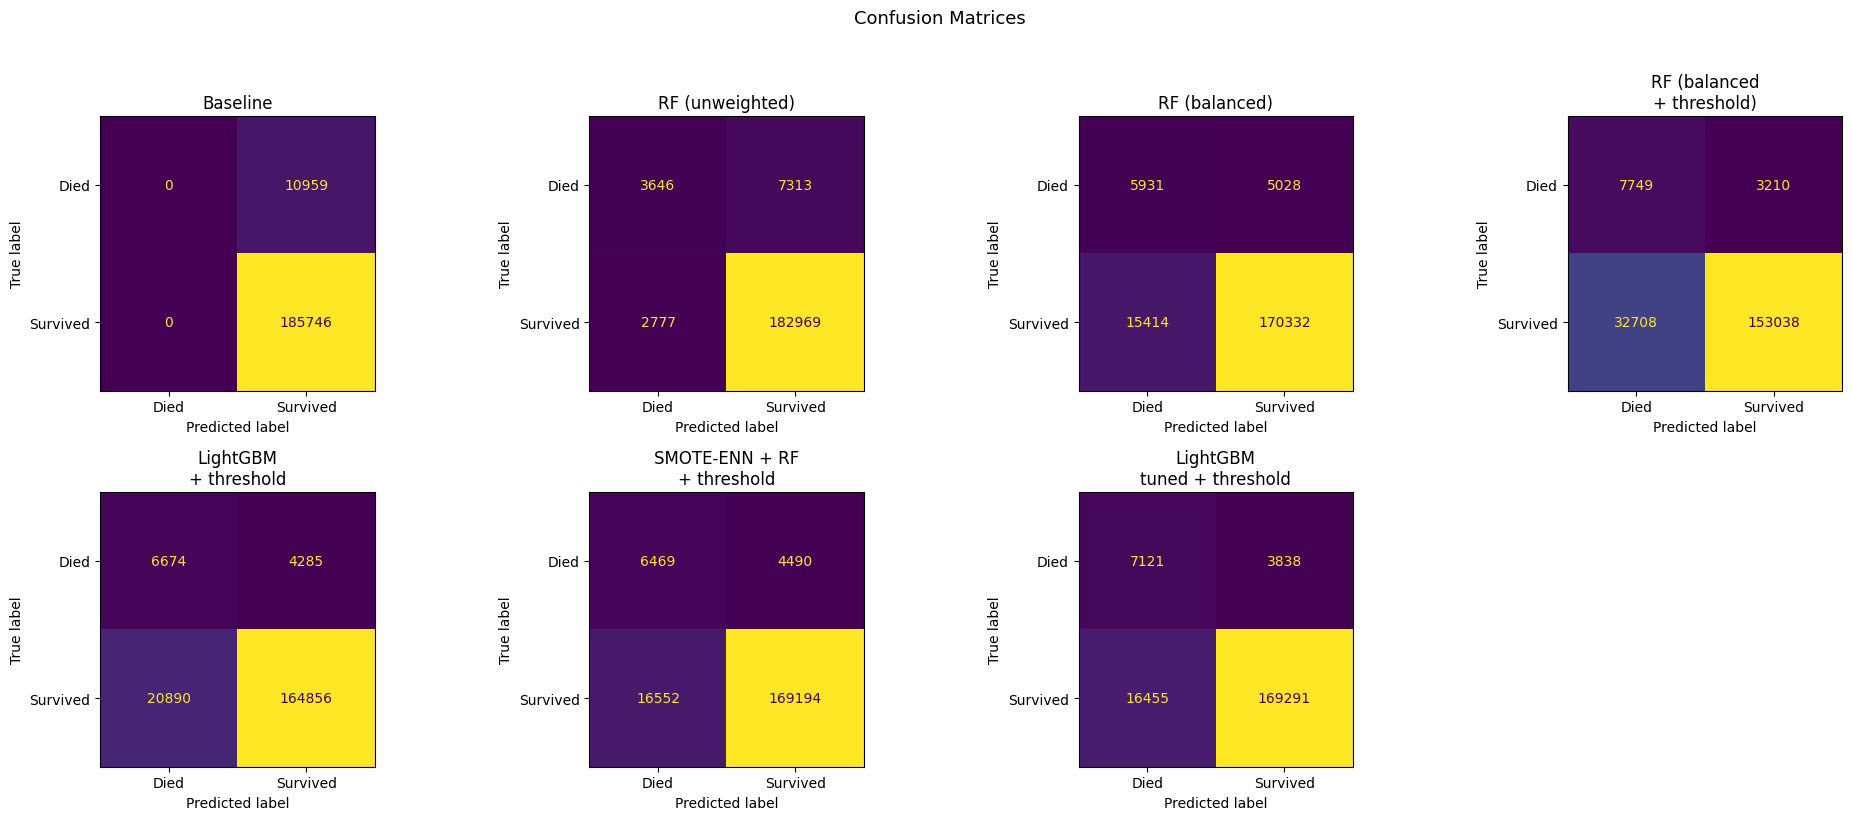

In [28]:
# Confusion matrices (2 rows × 4 cols, last slot hidden)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, preds, title in zip(
    axes,
    [y_pred_baseline, y_pred_case1, y_pred_case2, y_pred_case3, y_pred_case4, y_pred_case5, y_pred_case6],
    ["Baseline", "RF (unweighted)", "RF (balanced)", "RF (balanced\n+ threshold)", "LightGBM\n+ threshold", "SMOTE-ENN + RF\n+ threshold", "LightGBM\ntuned + threshold"],
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, preds),
        display_labels=["Died", "Survived"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(title)

axes[-1].set_visible(False)  # hide unused 8th slot
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

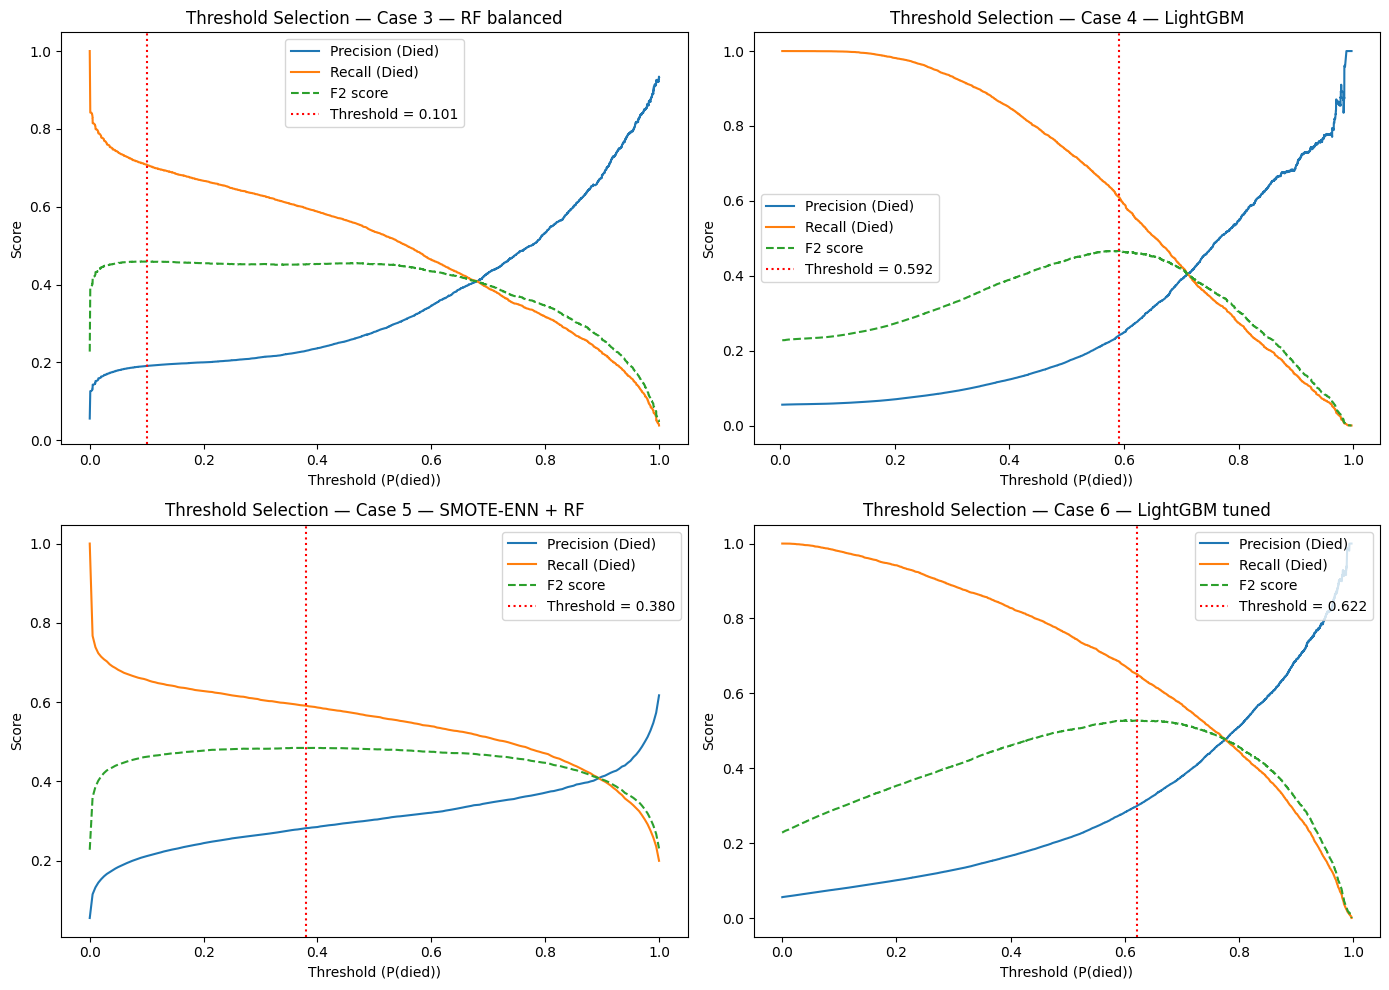

In [29]:
# Precision-Recall curves for Cases 3, 4, 5, 6 threshold selection

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, precisions_, recalls_, thresholds_, f2_scores_, best_threshold_, case_label in [
    (axes[0], precisions, recalls, thresholds, f2_scores, best_threshold, "Case 3 — RF balanced"),
    (axes[1], precisions_c4, recalls_c4, thresholds_c4, f2_scores_c4, best_threshold_c4, "Case 4 — LightGBM"),
    (axes[2], precisions_c5, recalls_c5, thresholds_c5, f2_scores_c5, best_threshold_c5, "Case 5 — SMOTE-ENN + RF"),
    (axes[3], precisions_c6, recalls_c6, thresholds_c6, f2_scores_c6, best_threshold_c6, "Case 6 — LightGBM tuned"),
]:
    ax.plot(thresholds_, precisions_[:-1], label="Precision (Died)")
    ax.plot(thresholds_, recalls_[:-1], label="Recall (Died)")
    ax.plot(thresholds_, f2_scores_[:-1], label="F2 score", linestyle="--")
    ax.axvline(best_threshold_, color="red", linestyle=":", label=f"Threshold = {best_threshold_:.3f}")
    ax.set_xlabel("Threshold (P(died))")
    ax.set_ylabel("Score")
    ax.set_title(f"Threshold Selection — {case_label}")
    ax.legend()

plt.tight_layout()
plt.show()

#### Prediction Function

In [30]:
active_pipeline = pipeline_lgbm_tuned
active_threshold = best_threshold_c6  # set to 0.5 to revert to default behaviour


def generate_warnings(species_name, temp, rain, elev, slope, ph):
    warnings = []
    if not (final_df["slope_mean"].min() <= slope <= final_df["slope_mean"].max()):
        warnings.append("Slope is outside the observed farm conditions")
    row = optima_df.loc[optima_df["species_name"] == species_name]
    if row.empty:
        warnings.append("Species not found in optimal range table")
        return warnings
    r = row.iloc[0]
    if not (r["rainfall_min"] <= rain <= r["rainfall_max"]):
        warnings.append("Rainfall is outside the species' optimal range")
    if not (r["temp_min"] <= temp <= r["temp_max"]):
        warnings.append("Temperature is outside the species' optimal range")
    if not (r["ph_min"] <= ph <= r["ph_max"]):
        warnings.append("Soil pH is outside the species' optimal range")
    if not (r["alt_min"] <= elev <= r["alt_max"]):
        warnings.append("Altitude is outside the species' optimal range")
    return warnings


def predict_survival(species_name, temp, rain, elev, slope, ph, trunk_circumference, planted_month, age_months):
    for w in generate_warnings(species_name, temp, rain, elev, slope, ph):
        print("Note:", w)
    print()

    # Compute optimum distance features from species optima table
    opt_row = optima_df.loc[optima_df["species_name"] == species_name]
    if opt_row.empty:
        rain_outside = temp_outside = elev_outside = ph_outside = 0.0
    else:
        r = opt_row.iloc[0]
        rain_outside = float(_outside_range(rain, r["rainfall_min"], r["rainfall_max"]))
        temp_outside = float(_outside_range(temp, r["temp_min"], r["temp_max"]))
        elev_outside = float(_outside_range(elev, r["alt_min"], r["alt_max"]))
        ph_outside = float(_outside_range(ph, r["ph_min"], r["ph_max"]))

    sample = pd.DataFrame(
        [
            {
                "temp_mean": temp,
                "rain_mean": rain,
                "elev_mean": elev,
                "slope_mean": slope,
                "ph": ph,
                "correct_tree_species_name": species_name,
                "trunk_circumference": trunk_circumference,
                "planted_month": planted_month,
                "age_months": age_months,
                "rain_outside_opt": rain_outside,
                "temp_outside_opt": temp_outside,
                "elev_outside_opt": elev_outside,
                "ph_outside_opt": ph_outside,
            }
        ]
    )
    prob_survived = active_pipeline.predict_proba(sample)[0][1]
    prediction = "Survived" if prob_survived > 1 - active_threshold else "Died"
    print(f"Predicted survival chance for '{species_name}': {prob_survived * 100:.2f}%")
    print(f"Prediction (threshold={active_threshold:.3f})  : {prediction}")

#### Visual comparison of models

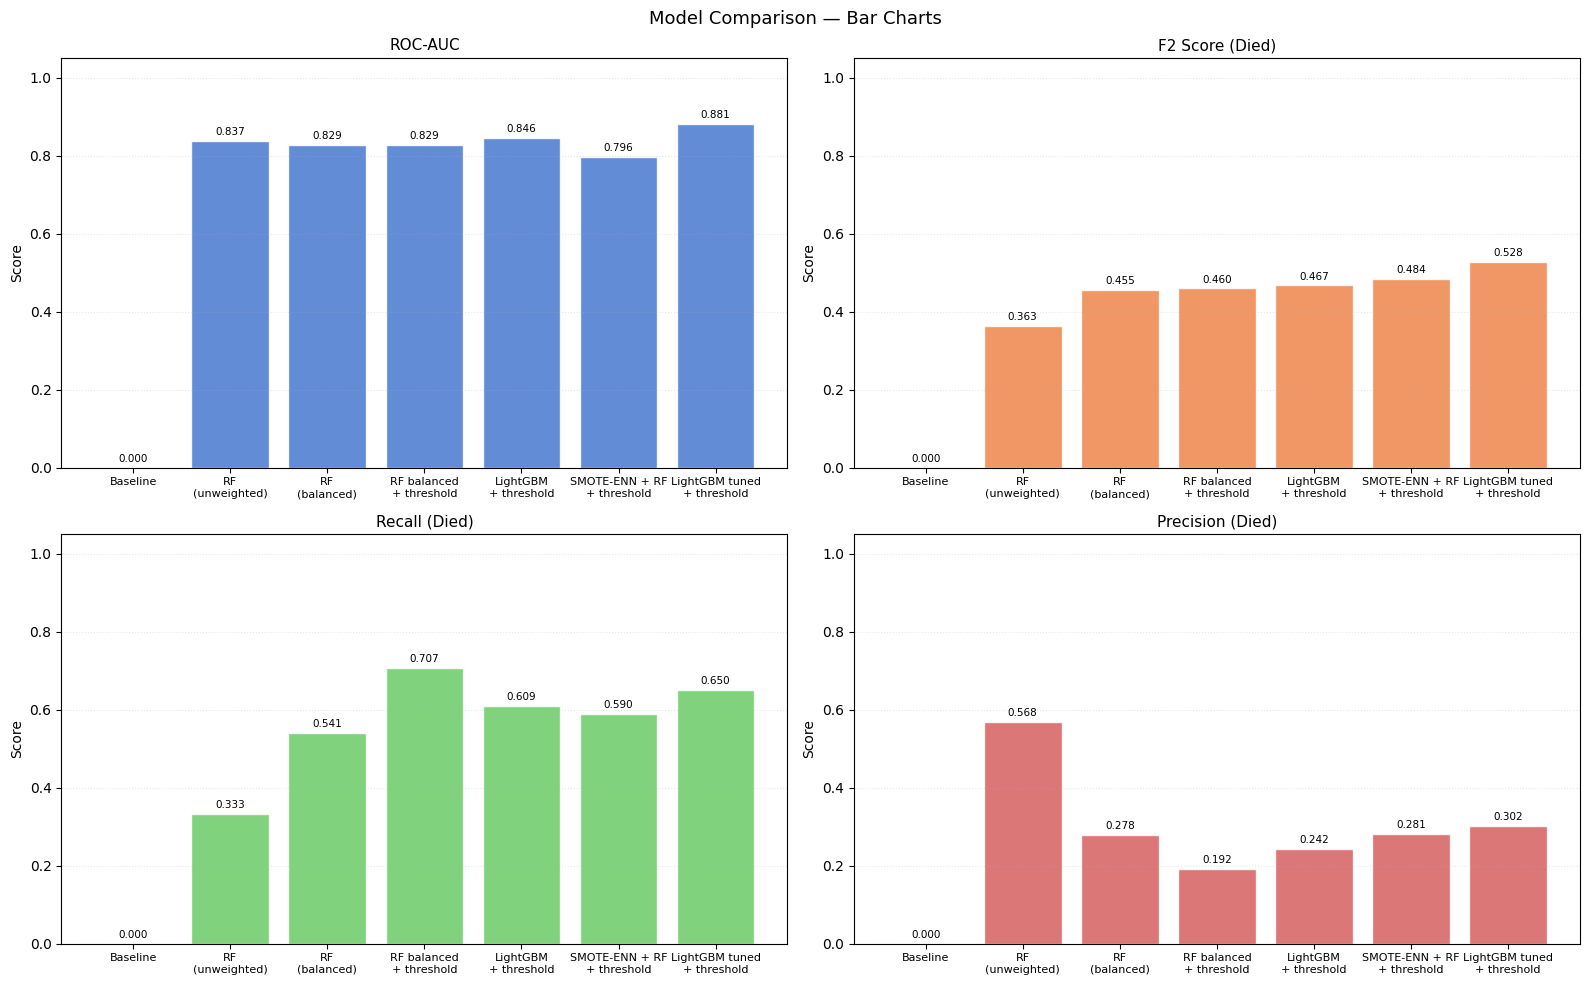

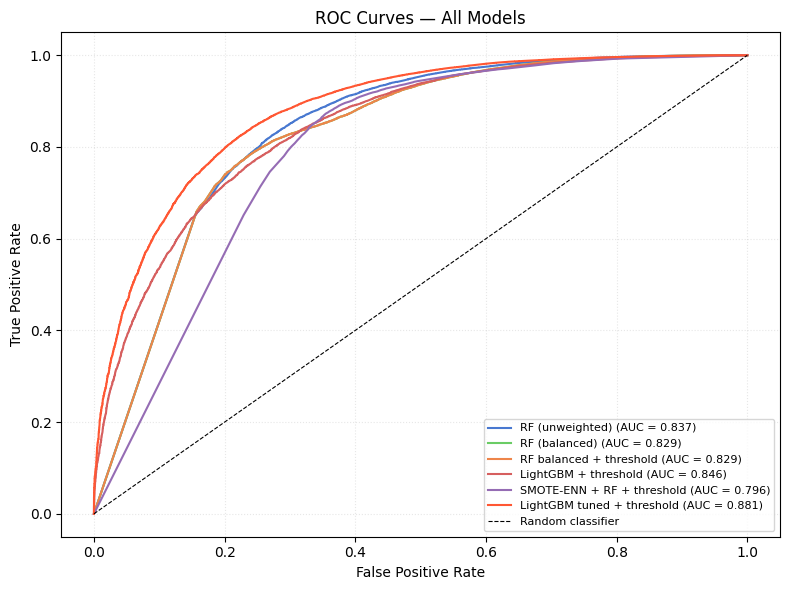

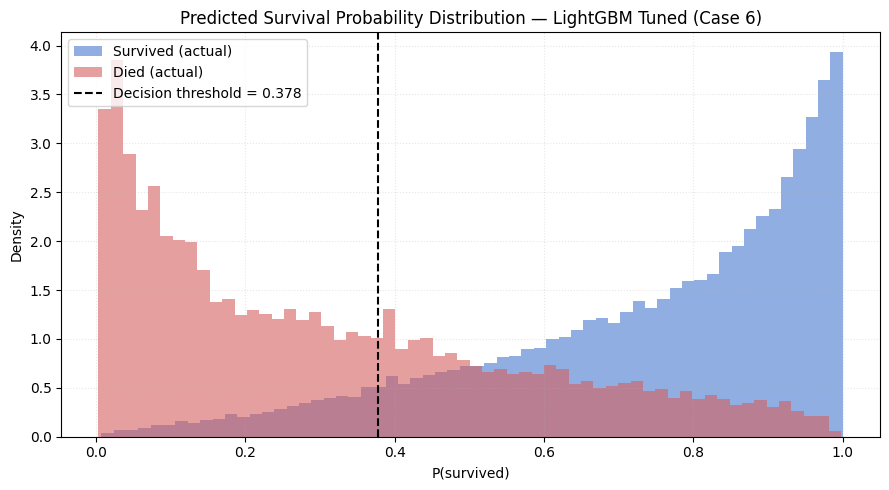

In [31]:
model_specs = [
    ("Baseline", y_pred_baseline, None),
    ("RF\n(unweighted)", y_pred_case1, y_prob_case1),
    ("RF\n(balanced)", y_pred_case2, y_prob_case2),
    ("RF balanced\n+ threshold", y_pred_case3, y_prob_case3),
    ("LightGBM\n+ threshold", y_pred_case4, y_prob_case4),
    ("SMOTE-ENN + RF\n+ threshold", y_pred_case5, y_prob_case5),
    ("LightGBM tuned\n+ threshold", y_pred_case6, y_prob_case6),
]

model_names = [m[0] for m in model_specs]
model_preds = [m[1] for m in model_specs]
model_probs = [m[2] for m in model_specs]

roc_aucs = [roc_auc_score(y_test, p) if p is not None else 0.0 for p in model_probs]
f2_died = [fbeta_score(y_test, p, beta=2, pos_label=0, zero_division=0) for p in model_preds]
recall_died = [recall_score(y_test, p, pos_label=0, zero_division=0) for p in model_preds]
prec_died = [precision_score(y_test, p, pos_label=0, zero_division=0) for p in model_preds]

x = np.arange(len(model_names))

# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, values, title, colour in zip(
    axes.flatten(),
    [roc_aucs, f2_died, recall_died, prec_died],
    ["ROC-AUC", "F2 Score (Died)", "Recall (Died)", "Precision (Died)"],
    ["#4878d0", "#ee854a", "#6acc65", "#d65f5f"],
):
    bars = ax.bar(x, values, color=colour, alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Score")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.grid(axis="y", alpha=0.3, linestyle=":")

plt.suptitle("Model Comparison — Bar Charts", fontsize=13)
plt.tight_layout()
plt.show()

# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colours = ["#999999", "#4878d0", "#6acc65", "#ee854a", "#d65f5f", "#956cb4", "#ff5733"]

for (name, _, prob), colour in zip(model_specs, colours):
    if prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=colour, lw=1.5, label=f"{name.replace(chr(10), ' ')} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# ── Predicted probability distribution — Case 6 (best model) ─────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_prob_case6[y_test == 1], bins=60, alpha=0.6, color="#4878d0", density=True, label="Survived (actual)")
ax.hist(y_prob_case6[y_test == 0], bins=60, alpha=0.6, color="#d65f5f", density=True, label="Died (actual)")
ax.axvline(1 - best_threshold_c6, color="black", linestyle="--", lw=1.5, label=f"Decision threshold = {1 - best_threshold_c6:.3f}")
ax.set_xlabel("P(survived)")
ax.set_ylabel("Density")
ax.set_title("Predicted Survival Probability Distribution — LightGBM Tuned (Case 6)")
ax.legend()
ax.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

#### Key Findings

##### Feature Engineering Was the Critical Bottleneck

All early models (Cases 1-4) trained on the original 6 environmental features (temperature, rainfall, elevation, slope, pH, species) plateaued at **ROC-AUC ≈ 0.754**. Adding 7 engineered features broke through to **ROC-AUC 0.881**:

- `trunk_circumference` - proxy for tree health and age at scan time
- `planted_month` - captures seasonal planting effects
- `age_months` - tree age in months at time of scan
- `rain_outside_opt`, `temp_outside_opt`, `elev_outside_opt`, `ph_outside_opt` - species-specific distance from optimal growing conditions (0 if within range, positive if outside)

##### Best Model: LightGBM Tuned and Threshold Moving (Case 6)

`RandomizedSearchCV` (20 iterations, 3-fold CV, scored on ROC-AUC) identified an optimal LightGBM configuration (255 leaves, learning rate 0.1, L1/L2 regularisation). Probability threshold tuning on the validation set using F2 score (β=2) further boosted recall for the minority "Died" class - an acceptable trade-off since missing a tree at risk is more costly than a false alarm.

- **ROC-AUC : 0.881** - strong separation between survivors and deaths
- **Recall (Died) : 65%** - correctly flags ~2 in 3 trees that will die
- **Precision (Died) : 30%** - 1 in 3 flagged trees are actually at risk
- **F2 (Died) : 0.528** - best recall-weighted performance across all models




*Note: The user documentation for this survivability model has been saved in `/datascience/docs/tree_survivability_model_doc.md`*
